In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

# Logisitic Regression from scratch (Numpy)

In [ ]:
N = 100
x1 = np.random.randn(N, 2) + np.array([[1,2]])
y1 = np.ones((N, 1))
x2 = np.random.randn(N, 2) + np.array([[-1,-2]])
y2 = np.zeros((N, 1))

X = np.concatenate([x1, x2], axis=0)
y = np.concatenate([y1, y2], axis=0)
# adding bias as the first columns
v = np.ones((X.shape[0], 1))
X = np.concatenate([v, X], axis = 1)

In [ ]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def loss_fn(yhat, y):
  return np.mean(-y * np.log(yhat+1e-7) - (1 - y) * np.log(1 - yhat+1e-7), axis = 0)

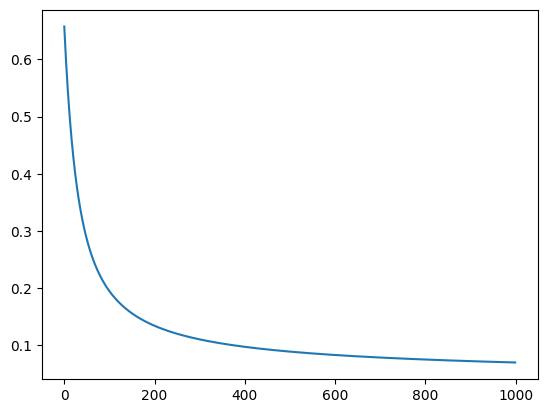

In [ ]:
epochs = 1000
lr = 0.0001
ls = []
# w represents theta
w = np.random.randn(3, 1)
for i in range(epochs):
  # forward pass
  z = X @ w
  yhat = sigmoid(z)
  loss = loss_fn(yhat, y)
  ls.append(loss)
  # backward pass
  dw = X.T @ (yhat - y)

  # optimization
  w = w - lr * dw

plt.plot(ls)

# Logisitic Regression using (Sklearn)

In [ ]:
dataset = load_breast_cancer()

In [ ]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

In [ ]:
X = df.drop('target', axis = 1)
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
yhat_train = model.predict(X_train)
yhat_test = model.predict(X_test)

In [ ]:
accuracy_train = accuracy_score(yhat_train, y_train)
accuracy_test = accuracy_score(yhat_test, y_test)

In [ ]:
print(accuracy_train, accuracy_test)

0.9472527472527472 0.9122807017543859


In [ ]:
train_loss = log_loss(yhat_train, y_train)
test_loss = log_loss(yhat_test, y_test)

In [ ]:
print(train_loss, test_loss)

1.9012036952501357 3.1617239815015044
